In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('../../data/Housing.csv')

print(data.size)

X = data['area'].values

y = data['price'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)
def normalize(arr):
    return arr / arr.max() 
    # return (arr - arr.min()) / (arr.max() - arr.min())
  

# NORMAILZE
X_train = normalize(X_train)
X_test = normalize(X_test)


y_train = normalize(y_train)
y_test = normalize(y_test)

print(X_train[:5])
print(X_test[:5])



print(y_train[:5])
print(y_test[:5])




94981
[0.35787157 0.9029806  0.57011402 0.12562513 0.10182036]
[0.72080913 0.49789706 0.15141198 0.43601041 0.5607851 ]
[0.35736465 0.85789685 0.55525503 0.10270462 0.15837836]
[0.72624004 0.52481871 0.104501   0.415078   0.5572136 ]


In [3]:
m = 0
b = 0 
learning_rate = 0.01
epochs = 10000
losses = []
n = len(X_train)

for i in range(epochs):
    
    y_pred = m * X_train + b
    
    dm = (-2/n) * np.sum(X_train * (y_train - y_pred))
    db = (-2/n) * np.sum(y_train - y_pred)
    
    loss = np.mean((y_train - y_pred) ** 2)

    losses.append(loss)

    m = m - learning_rate * dm
    b = b - learning_rate * db

print("Gradient Descent Slope:", m)
print("Gradient Descent Intercept:", b)


Gradient Descent Slope: 0.9030698295134432
Gradient Descent Intercept: 0.03391570921456384


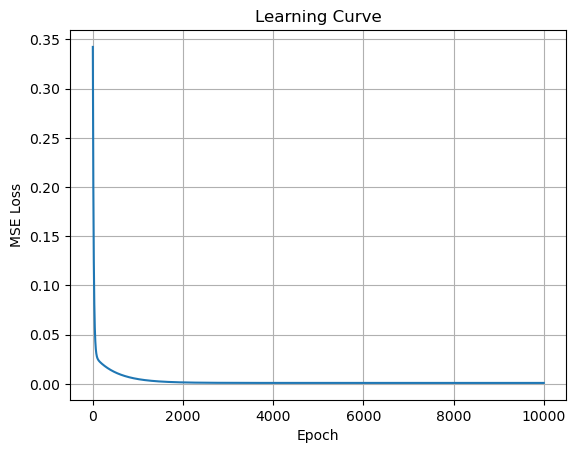

In [4]:
# learning curve Epochs vs Loss

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Curve")
plt.grid(True)
plt.show()

[0.35709874 0.84937023 0.54876848 ... 0.63024167 0.72887662 0.30200046]


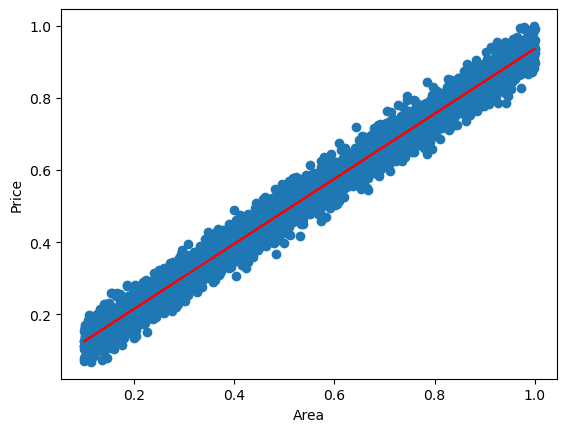

In [5]:

plt.scatter(X_train,y_train)
print(y_pred)
plt.plot(X_train, y_pred , color = 'red')

plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [6]:
#Vectorize
learning_rate = 0.1
features = np.array((X_train , np.ones(len(X_train)))).T
parameters = np.zeros(features.shape[1])
print(features)
print(parameters)
n = len(X_train)

[[0.35787157 1.        ]
 [0.9029806  1.        ]
 [0.57011402 1.        ]
 ...
 [0.66033207 1.        ]
 [0.76955391 1.        ]
 [0.29685937 1.        ]]
[0. 0.]


In [7]:
for i in range(epochs):
    y_pred = np.dot(features , parameters)
    gradient = (2/n) * np.dot(features.T, (y_pred - y_train))
    parameters = parameters - (learning_rate * gradient)

y_pred = np.dot(features , parameters)

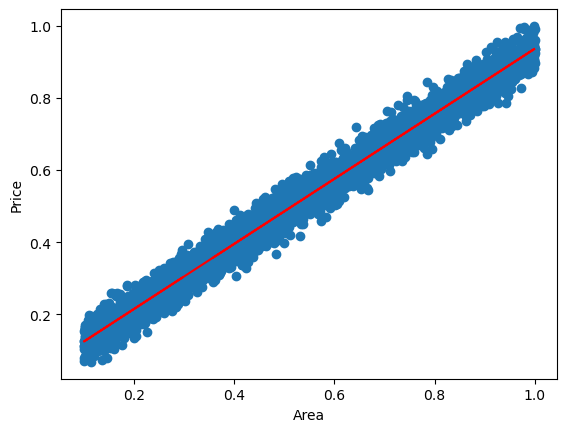

In [8]:

plt.scatter(X_train,y_train)

plt.plot(X_train, y_pred , color = 'red')

plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [10]:
# evaluate
#Vectorize

features = np.array((X_test , np.ones(len(X_test)))).T
y_pred = np.dot(features , parameters)

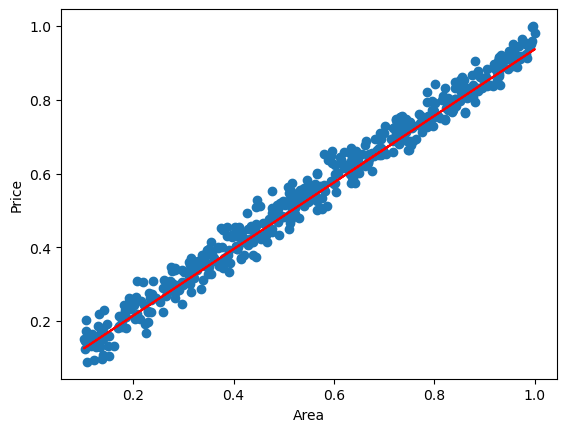

In [12]:

plt.scatter(X_test,y_test)

plt.plot(X_test, y_pred , color = 'red')

plt.xlabel("Area")
plt.ylabel("Price")
plt.show()